# Quality Assessment and Optimization Notebook

## 1. Importing Libraries and Loading Data
This section introduces the notebook by importing the necessary libraries (such as pandas, NumPy, matplotlib, and scikit-learn) and loading the dataset from a CSV file. A preview of the dataset is displayed to confirm that the data has been loaded correctly.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Increase plot size for readability
plt.rcParams["figure.figsize"] = (10, 6)

# Load the dataset
file_path = "Kelloe mains Harvest_2023(2).csv"
df = pd.read_csv(file_path)

# Preview the dataset
print("Dataset preview:")
print(df.head())


Dataset preview:
    Clients         Farms     Fields               Machine Name  \
0  Mcdonald  kelloe mains     birsby  8500i - SL22 SYY (R Wood)   
1  Mcdonald  kelloe mains     birsby  8400i - SK19 LFR (R Wood)   
2  Mcdonald  kelloe mains     birsby  8400i - SK16 GTY (R Wood)   
3  Mcdonald  kelloe mains     birsby  8500i - SL22 SYY (R Wood)   
4  Mcdonald  kelloe mains  Craig mae  8500i - SL22 SYY (R Wood)   

           Equipment         Operators Varieties  \
0  1Z08500YANU622386  Unknown Operator   1ST Cut   
1  1Z08400YEKU619149  Unknown Operator   2ND CUT   
2  1Z08400YJGR515326  Unknown Operator   3RD CUT   
3  1Z08500YANU622386  Unknown Operator   4TH CUT   
4  1Z08500YANU622386  Unknown Operator   1ST Cut   

                                            Work     Crop Type  \
0  Forage Harvesting Grass Forage - May 17, 2023  Grass Forage   
1  Forage Harvesting Grass Forage - Jun 13, 2023  Grass Forage   
2  Forage Harvesting Grass Forage - Jul 20, 2023  Grass Forage   
3  

## 2. Data Cleaning and Preprocessing for Quality Assessment
In this section, the data is prepared for quality analysis by:
- Converting specific columns (like "Area Harvested", "Moisture", "Dry Yield", "Speed", "Total Fuel", "Fuel Efficiency", and "Crude Protein") into numeric formats, while handling any non-numeric placeholders.
- Dropping rows with missing values in the predictors or the quality target ("Crude Protein").
This step ensures that the dataset is clean and consistent for building the quality prediction model.


In [3]:
# Helper function to convert columns to numeric values (handling placeholders like '---')
def to_numeric(col):
    return pd.to_numeric(col.replace('---', np.nan), errors='coerce')

# Define predictor features and the quality target ("Crude Protein")
predictors = ["Area Harvested", "Moisture", "Dry Yield", "Speed", "Total Fuel", "Fuel Efficiency"]
target_quality = "Crude Protein"

# Convert the selected columns to numeric
for col in predictors + [target_quality]:
    df[col] = to_numeric(df[col])

# Drop rows with missing values in the predictors or the quality target
df_quality = df.dropna(subset=predictors + [target_quality])
print("Cleaned data shape for quality assessment:", df_quality.shape)


Cleaned data shape for quality assessment: (47, 65)


## 3. Exploratory Data Analysis (EDA)
This section explores the relationships between the selected predictor features and the quality target ("Crude Protein") by generating scatter plots. These visualizations help to:
- Identify trends and correlations between individual features and the quality metric.
- Gain insights that can inform further feature engineering and model selection.

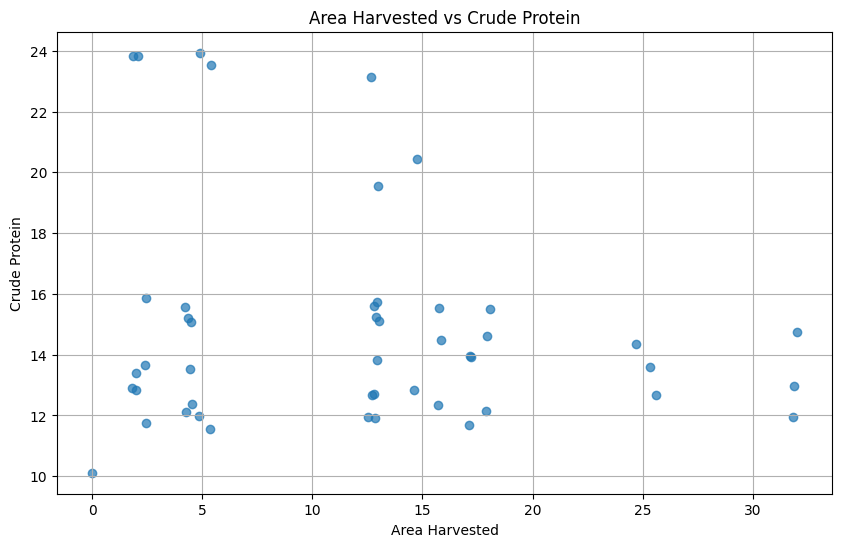

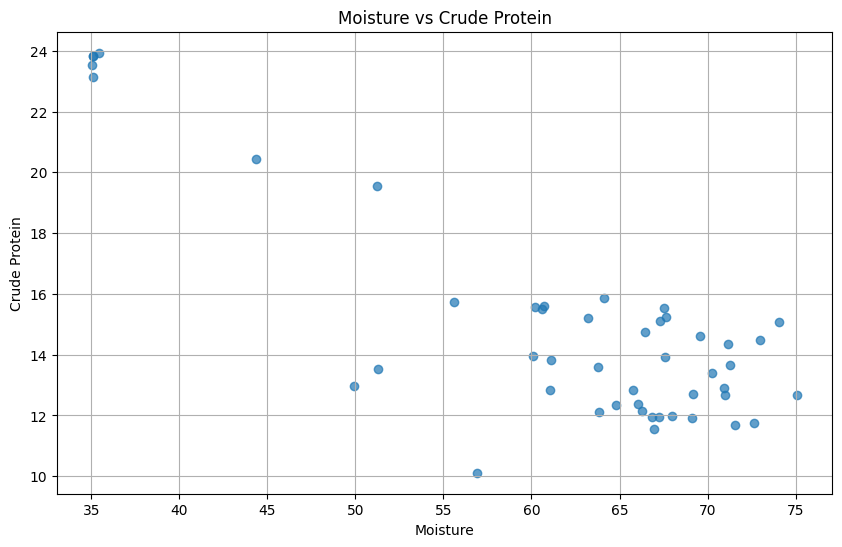

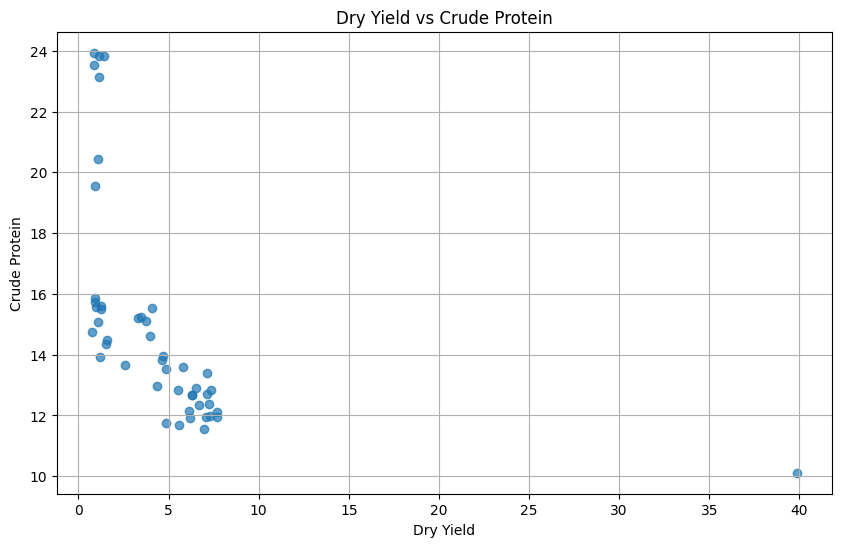

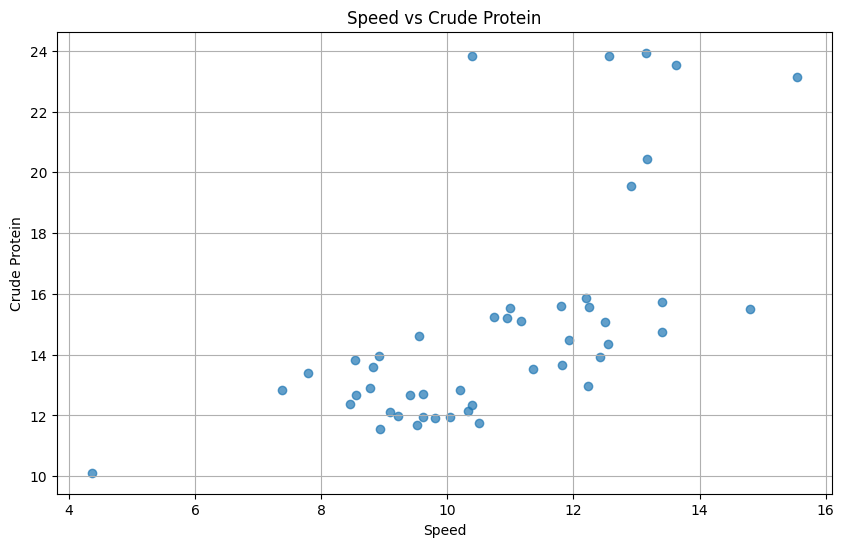

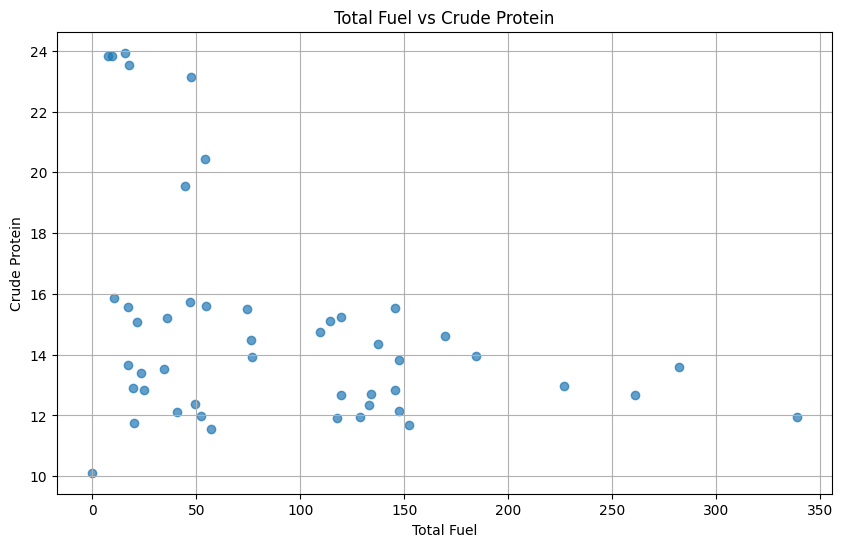

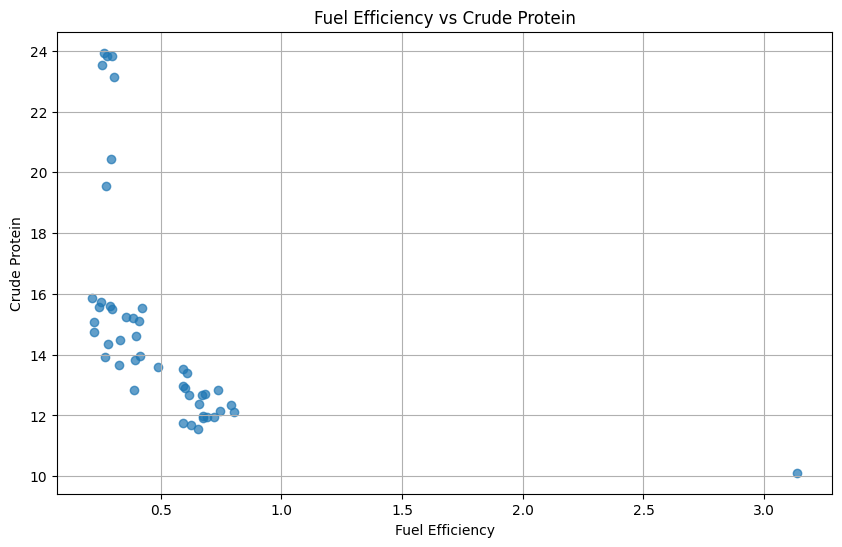

In [4]:
# Generate scatter plots for each predictor vs. the quality target ("Crude Protein")
for predictor in predictors:
    plt.figure()
    plt.scatter(df_quality[predictor], df_quality[target_quality], alpha=0.7)
    plt.xlabel(predictor)
    plt.ylabel(target_quality)
    plt.title(f"{predictor} vs {target_quality}")
    plt.grid(True)
    plt.show()


## 4. Building the Regression Model for Quality Prediction
Here, the notebook outlines the process of constructing a predictive model:
- The clean dataset is divided into training and testing sets.
- A Linear Regression model is initialized and trained using the predictor features.
- The goal is to predict the quality metric ("Crude Protein") based on the operational data, establishing a baseline for quality prediction.



In [5]:
# Define X (predictors) and y (quality target)
X_quality = df_quality[predictors]
y_quality = df_quality[target_quality]

# Split the data into training and testing sets (80% train, 20% test)
X_train_q, X_test_q, y_train_q, y_test_q = train_test_split(X_quality, y_quality, test_size=0.2, random_state=42)

# Initialize and train a Linear Regression model
quality_model = LinearRegression()
quality_model.fit(X_train_q, y_train_q)

# Make predictions on the test set
y_pred_q = quality_model.predict(X_test_q)


## 5. Evaluating the Model and Visualizing Predictions
This section focuses on evaluating the performance of the quality prediction model by:
- Calculating evaluation metrics such as Mean Squared Error (MSE) and R-squared.
- Visualizing the comparison between actual and predicted "Crude Protein" values using a scatter plot.
- Including an ideal prediction line to help assess the model’s accuracy and identify areas for improvement.


Quality Model Evaluation:
Mean Squared Error (MSE): 4.5206763099179135
R-squared: 0.786250135895984


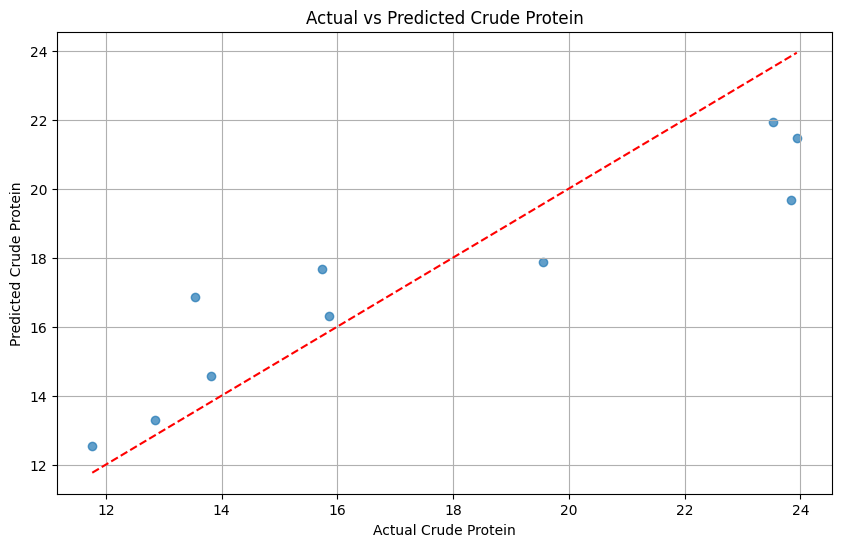

In [6]:
# Calculate evaluation metrics: Mean Squared Error (MSE) and R-squared
mse_quality = mean_squared_error(y_test_q, y_pred_q)
r2_quality = r2_score(y_test_q, y_pred_q)

print("Quality Model Evaluation:")
print("Mean Squared Error (MSE):", mse_quality)
print("R-squared:", r2_quality)

# Create a scatter plot comparing actual vs. predicted values for "Crude Protein"
plt.figure()
plt.scatter(y_test_q, y_pred_q, alpha=0.7)
plt.xlabel("Actual Crude Protein")
plt.ylabel("Predicted Crude Protein")
plt.title("Actual vs Predicted Crude Protein")
plt.plot([y_test_q.min(), y_test_q.max()], [y_test_q.min(), y_test_q.max()], 'r--')  # Ideal prediction line
plt.grid(True)
plt.show()


## 6. Next Steps
The final section outlines future enhancements and considerations:
- **Feature Engineering:** Explore additional variables or create composite indices to potentially improve model performance.
- **Advanced Modeling:** Experiment with more complex regression models (such as Random Forest or Gradient Boosting) and perform hyperparameter tuning.
- **Cross-Validation:** Implement cross-validation techniques to ensure robustness of the model.
- **Additional Metrics:** Consider analyzing and predicting other quality metrics like "Metabolizable Energy" or "Dry Matter."
This roadmap provides guidance for refining the model and further optimizing quality assessment.